In [185]:

# NOTE
# Use training, test, validation sets (done)

# Task 1.1
# Apply test data. Calculate differences between original and reconstructed patches
# With beta and with no beta (done)

# Task 1.2
# Plot latent vector distribution for the mean matrix (DONE)

# Task 1.3 
# Plot the curve for KL divergence (DONE)

# Task 1.4
# Filter out empty patches (DONE)


In [186]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec

In [187]:
# References
# https://datatas.com/how-to-use-variational-autoencoders-for-large-scale-data-compression/

In [188]:
# Task:
# Create plot with train loss, test loss, valid loss
# Plots with different betas
# Check what error curves are good for VAE
# Plot before and after plots

In [189]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25

In [190]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    # print(encoded_width, encoded_height, np.log2(num_embeddings))
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total.astype(np.uint8)

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount) * encoded_patch_bits

# TODO: test the method
def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    
    total_bits = _get_total_hit_bits(n_hits_total)
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
    event_patches_adcs = [
        event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
        for event_patch_flat in event_patches_adcs_flat
    ]
    return len(event_patches_adcs)

    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [191]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:03<00:00, 274.65it/s]


In [ ]:
batch_size = 64
# beta = 0
beta = 1e-5
learning_rate = 1e-3
num_epochs = 80
channels = 1
latent_dim = 128

# logs
LOG_EVERY = 10


In [193]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [194]:
mse = MeanSquaredError()
mse = mse.to(device)

In [195]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [196]:
event_train = events_train[:SELECTED_EVENTS][0]

In [197]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
            if not (np.all(event_patch_flat == 0))
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [ ]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")


# EXAMPLE with events test
# train_loader = DataLoader(
#     dataset=event_dataset, 
#     batch_size=batch_size
# )

# # Test data preparation
# events_test_loaders = []
# for event_test in events_test:
#     event_dataset = PixelPatchesDataset(event_test, transform)

#     event_test_loader = DataLoader(
#         dataset=event_dataset, 
#         batch_size=batch_size
#     )
#     events_test_loaders.append(event_test_loader)

Training set size: 12685
Validation set size: 1585
Test set size: 1587


In [199]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor, 
    mu: torch.tensor, 
    logvar: torch.tensor
) -> float:
    # recon_loss = F.mse_loss(
    #     recon_x, 
    #     x, 
    #     reduction="sum"
    # ) / x.size(0)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    
    # KL_divergence
    kl_loss = -0.5 * (
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    
    kl_loss = kl_loss.mean()
    
    return (
        recon_loss + beta * kl_loss,
        recon_loss,
        beta,
        kl_loss
    )

In [200]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, hidden_channels * 2, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
        )
        # self.flatten = nn.Flatten()
        self.fc_mean = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        self.fc_log_var = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        # self.fc_mean = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )
        torch.nn.init.xavier_uniform_(self.fc_mean.weight)
        
        # self.fc_log_var = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )        
        torch.nn.init.xavier_uniform_(self.fc_log_var.weight)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        x_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        z_log_mean = self.fc_mean(x_encoded)
        z_log_var = self.fc_log_var(x_encoded)
        
        self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        # self.z_log_var = torch.clamp(z_log_var, min=-8, max=1)
        self.z_log_var = torch.tanh(z_log_var) * 8
        
        # sample a latent vector using the reparameterization trick
        
        z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        output = self.decoder(z)
        
        return output, self.z_log_mean, self.z_log_var, z

In [201]:
model = VAE(
    hidden_channels=64, 
    kernel_size = 4,
    slope=0.01
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 496.80it/s, Loss=0.0339]


Epoch [1/80]Average Loss: BCE = 0.0671, MSE = 0.007556535473243151, KL = 15.07205025634574
Average validation set BCE loss: 0.7097924041748047
Last validation batch patch mu and logvar:
mu: mean=0.0277, std=0.5548 | logvar: mean=-6.0422, std=1.4922
Before compression
Before: (64, 8, 8)


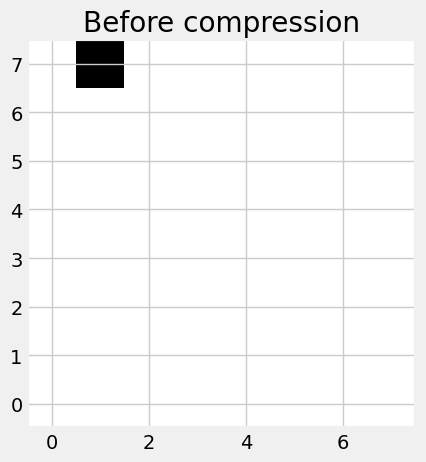

After: (1, 8, 8)
After compression


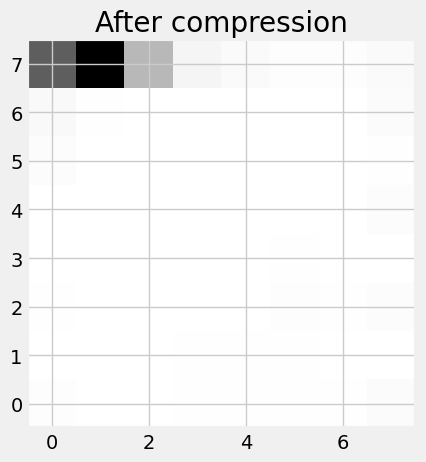

Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 506.45it/s, Loss=0.0275]


Epoch [2/80]Average Loss: BCE = 0.0360, MSE = 0.0027518183555706737, KL = 2.8328647673429557
Average validation set BCE loss: 0.36169538080692293


Epoch 3/80: 100%|██████████| 199/199 [00:00<00:00, 515.93it/s, Loss=0.0296]


Epoch [3/80]Average Loss: BCE = 0.0331, MSE = 0.0022696938117657173, KL = 2.979840216325156
Average validation set BCE loss: 0.29512436628341676


Epoch 4/80: 100%|██████████| 199/199 [00:00<00:00, 502.56it/s, Loss=0.0252]


...

Epoch [9/80]Average Loss: BCE = 0.0297, MSE = 0.0015340290680508966, KL = 3.1802893763211504
Average validation set BCE loss: 0.20027325212955474


Epoch 10/80: 100%|██████████| 199/199 [00:00<00:00, 511.33it/s, Loss=0.0288]


Epoch [10/80]Average Loss: BCE = 0.0295, MSE = 0.0014828346103977355, KL = 3.207597592368198
Average validation set BCE loss: 0.19989142179489136


Epoch 11/80: 100%|██████████| 199/199 [00:00<00:00, 510.62it/s, Loss=0.0374]


Epoch [11/80]Average Loss: BCE = 0.0293, MSE = 0.0014128908874752495, KL = 3.2203460901825873
Average validation set BCE loss: 0.18290643125772477
Last validation batch patch mu and logvar:
mu: mean=0.0248, std=0.7382 | logvar: mean=-6.9271, std=1.0784
Before compression
Before: (64, 8, 8)


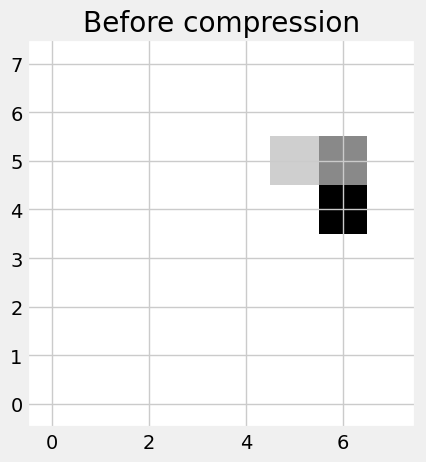

After: (1, 8, 8)
After compression


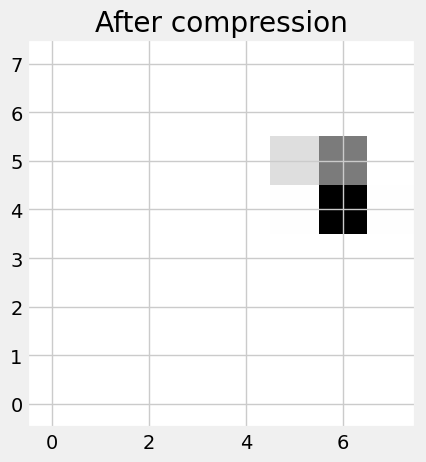

Epoch 12/80: 100%|██████████| 199/199 [00:00<00:00, 508.72it/s, Loss=0.0296]


Epoch [12/80]Average Loss: BCE = 0.0291, MSE = 0.00136720837560721, KL = 3.234619905002153
Average validation set BCE loss: 0.19009506791830064


Epoch 13/80: 100%|██████████| 199/199 [00:00<00:00, 511.61it/s, Loss=0.0301]


Epoch [13/80]Average Loss: BCE = 0.0289, MSE = 0.0013197436241372184, KL = 3.2511626715636135
Average validation set BCE loss: 0.18402125030755997


Epoch 14/80: 100%|██████████| 199/199 [00:00<00:00, 504.16it/s, Loss=0.0277]


...

Epoch [19/80]Average Loss: BCE = 0.0281, MSE = 0.001032487330893897, KL = 3.3077776132516528
Average validation set BCE loss: 0.16324019208550453


Epoch 20/80: 100%|██████████| 199/199 [00:00<00:00, 512.32it/s, Loss=0.0293]


Epoch [20/80]Average Loss: BCE = 0.0280, MSE = 0.0009756784727586312, KL = 3.317388663938896
Average validation set BCE loss: 0.15678441971540452


Epoch 21/80: 100%|██████████| 199/199 [00:00<00:00, 500.61it/s, Loss=0.0346]


Epoch [21/80]Average Loss: BCE = 0.0278, MSE = 0.0009136331196284698, KL = 3.3182264452603594
Average validation set BCE loss: 0.14665521919727326
Last validation batch patch mu and logvar:
mu: mean=0.0169, std=0.8074 | logvar: mean=-6.9880, std=1.0675
Before compression
Before: (64, 8, 8)


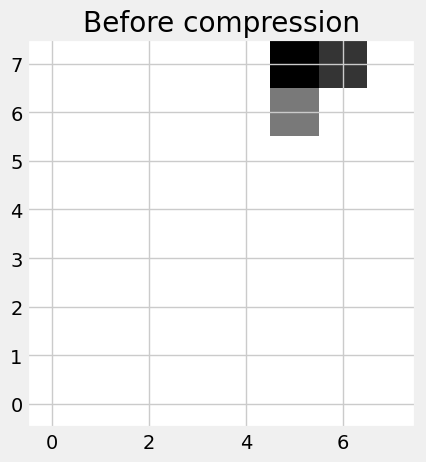

After: (1, 8, 8)
After compression


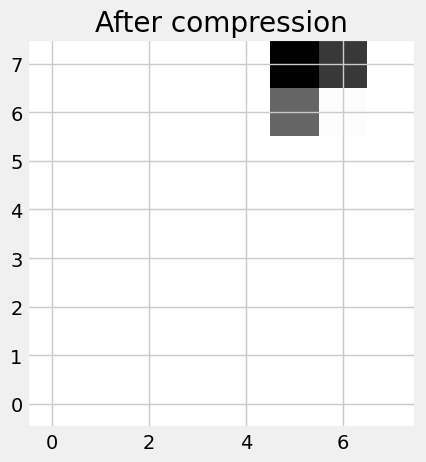

Epoch 22/80: 100%|██████████| 199/199 [00:00<00:00, 499.27it/s, Loss=0.0238]


Epoch [22/80]Average Loss: BCE = 0.0278, MSE = 0.0008911028729304764, KL = 3.3122391017837143
Average validation set BCE loss: 0.14816428527235984


Epoch 23/80: 100%|██████████| 199/199 [00:00<00:00, 511.88it/s, Loss=0.0272]


Epoch [23/80]Average Loss: BCE = 0.0277, MSE = 0.0008534515222731098, KL = 3.324187899354714
Average validation set BCE loss: 0.15886614248156547


Epoch 24/80: 100%|██████████| 199/199 [00:00<00:00, 509.19it/s, Loss=0.019] 


...

Epoch [29/80]Average Loss: BCE = 0.0271, MSE = 0.0006285674168597251, KL = 3.345167257078928
Average validation set BCE loss: 0.13771451532840728


Epoch 30/80: 100%|██████████| 199/199 [00:00<00:00, 498.45it/s, Loss=0.0245]


Epoch [30/80]Average Loss: BCE = 0.0270, MSE = 0.0005983836147711898, KL = 3.3460605935235717
Average validation set BCE loss: 0.13336032047867774


Epoch 31/80: 100%|██████████| 199/199 [00:00<00:00, 503.71it/s, Loss=0.0282]


Epoch [31/80]Average Loss: BCE = 0.0269, MSE = 0.0005695716752588805, KL = 3.35274864680803
Average validation set BCE loss: 0.12977262169122697
Last validation batch patch mu and logvar:
mu: mean=0.0232, std=0.8371 | logvar: mean=-7.0170, std=1.0473
Before compression
Before: (64, 8, 8)


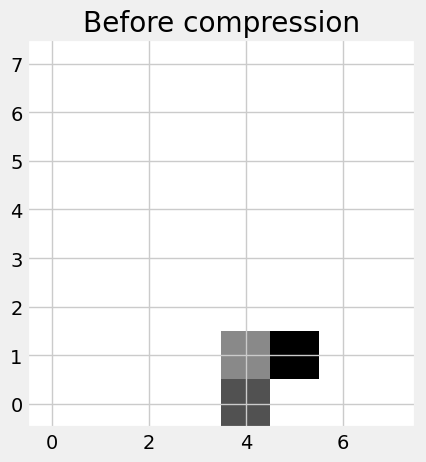

After: (1, 8, 8)
After compression


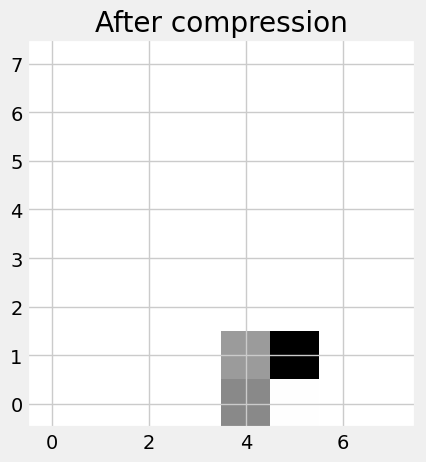

Epoch 32/80: 100%|██████████| 199/199 [00:00<00:00, 520.16it/s, Loss=0.0325]


Epoch [32/80]Average Loss: BCE = 0.0269, MSE = 0.0005549621039530001, KL = 3.3506692893541037
Average validation set BCE loss: 0.1321156071126461


Epoch 33/80: 100%|██████████| 199/199 [00:00<00:00, 509.42it/s, Loss=0.0211]


Epoch [33/80]Average Loss: BCE = 0.0268, MSE = 0.0005509893180440933, KL = 3.3551203461747674
Average validation set BCE loss: 0.12830377340316773


Epoch 34/80: 100%|██████████| 199/199 [00:00<00:00, 510.11it/s, Loss=0.0258]


...

Epoch [39/80]Average Loss: BCE = 0.0265, MSE = 0.0004626564701566304, KL = 3.372643045444584
Average validation set BCE loss: 0.12574263766407967


Epoch 40/80: 100%|██████████| 199/199 [00:00<00:00, 506.08it/s, Loss=0.0252]


Epoch [40/80]Average Loss: BCE = 0.0266, MSE = 0.00045554074397352736, KL = 3.3735921239134057
Average validation set BCE loss: 0.13277520179748536


Epoch 41/80: 100%|██████████| 199/199 [00:00<00:00, 500.73it/s, Loss=0.0295]


Epoch [41/80]Average Loss: BCE = 0.0265, MSE = 0.00042665657072840494, KL = 3.3753148323327453
Average validation set BCE loss: 0.1239982494711876
Last validation batch patch mu and logvar:
mu: mean=0.0248, std=0.8592 | logvar: mean=-7.0188, std=1.0530
Before compression
Before: (64, 8, 8)


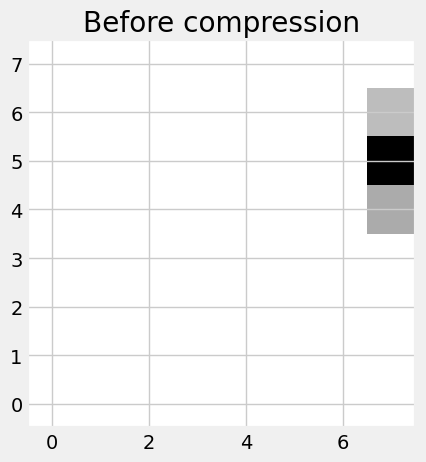

After: (1, 8, 8)
After compression


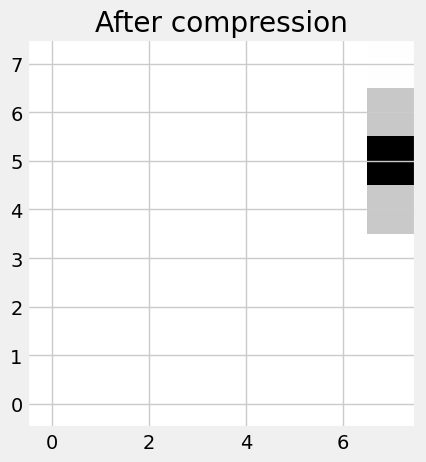

Epoch 42/80: 100%|██████████| 199/199 [00:00<00:00, 501.69it/s, Loss=0.0292]


Epoch [42/80]Average Loss: BCE = 0.0265, MSE = 0.0004117380719147529, KL = 3.3722728832283213
Average validation set BCE loss: 0.1294036389887333


Epoch 43/80: 100%|██████████| 199/199 [00:00<00:00, 501.58it/s, Loss=0.0364]


Epoch [43/80]Average Loss: BCE = 0.0264, MSE = 0.0003869299493565098, KL = 3.3747569280653145
Average validation set BCE loss: 0.12068826168775558


Epoch 44/80: 100%|██████████| 199/199 [00:00<00:00, 508.13it/s, Loss=0.0386]


...

Epoch [49/80]Average Loss: BCE = 0.0257, MSE = 0.00014316423785294775, KL = 3.3632105067746725
Average validation set BCE loss: 0.09093875795602799


Epoch 50/80: 100%|██████████| 199/199 [00:00<00:00, 517.68it/s, Loss=0.03]  


Epoch [50/80]Average Loss: BCE = 0.0257, MSE = 0.0001273821795420094, KL = 3.362065322435082
Average validation set BCE loss: 0.08931236073374749


Epoch 51/80: 100%|██████████| 199/199 [00:00<00:00, 526.20it/s, Loss=0.0274]


Epoch [51/80]Average Loss: BCE = 0.0257, MSE = 0.00011542967293088572, KL = 3.361031263916936
Average validation set BCE loss: 0.08822967305779457
Last validation batch patch mu and logvar:
mu: mean=0.0306, std=0.8697 | logvar: mean=-6.9796, std=1.0803
Before compression
Before: (64, 8, 8)


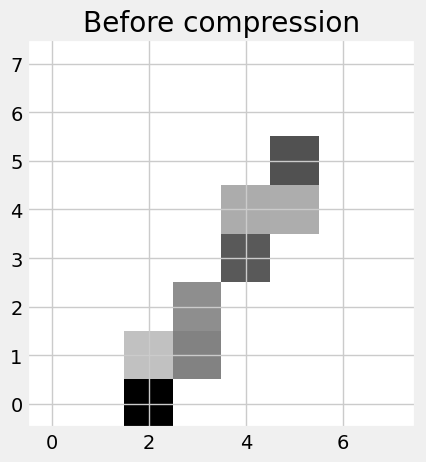

After: (1, 8, 8)
After compression


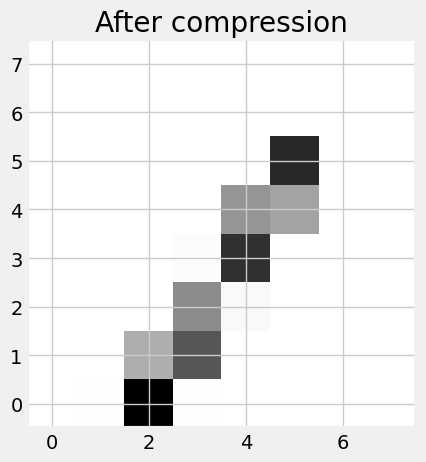

Epoch 52/80: 100%|██████████| 199/199 [00:00<00:00, 512.57it/s, Loss=0.032] 


Epoch [52/80]Average Loss: BCE = 0.0256, MSE = 9.843047531894946e-05, KL = 3.359989090780517
Average validation set BCE loss: 0.08253817573189735


Epoch 53/80: 100%|██████████| 199/199 [00:00<00:00, 525.90it/s, Loss=0.028] 


Epoch [53/80]Average Loss: BCE = 0.0256, MSE = 9.937677894404214e-05, KL = 3.356379939084077
Average validation set BCE loss: 0.08494449943304062


Epoch 54/80: 100%|██████████| 199/199 [00:00<00:00, 501.32it/s, Loss=0.0222]


...

Epoch [59/80]Average Loss: BCE = 0.0255, MSE = 7.251863523685354e-05, KL = 3.3494898062854555
Average validation set BCE loss: 0.07532103344798088


Epoch 60/80: 100%|██████████| 199/199 [00:00<00:00, 508.68it/s, Loss=0.0234]


Epoch [60/80]Average Loss: BCE = 0.0255, MSE = 6.62808041801985e-05, KL = 3.348837763819862
Average validation set BCE loss: 0.07221570566296577


Epoch 61/80: 100%|██████████| 199/199 [00:00<00:00, 523.75it/s, Loss=0.0204]


Epoch [61/80]Average Loss: BCE = 0.0254, MSE = 6.627053284977244e-05, KL = 3.3477111988930246
Average validation set BCE loss: 0.07339277639985084
Last validation batch patch mu and logvar:
mu: mean=0.0243, std=0.8607 | logvar: mean=-6.9614, std=1.0755
Before compression
Before: (64, 8, 8)


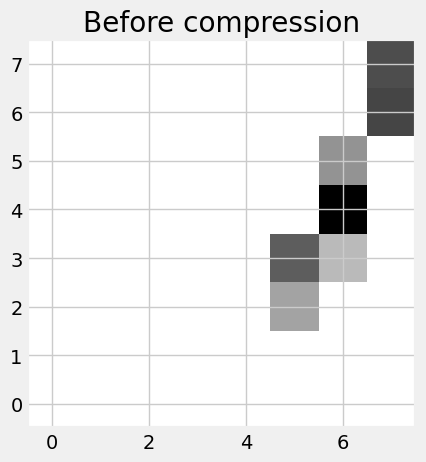

After: (1, 8, 8)
After compression


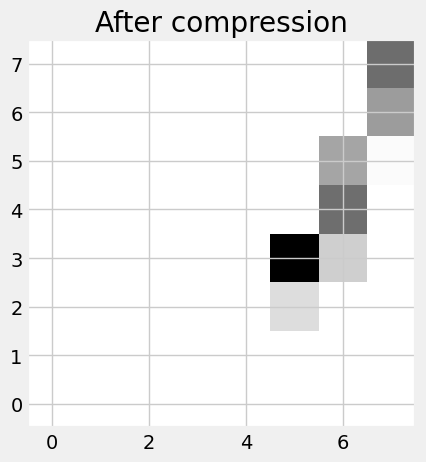

Epoch 62/80: 100%|██████████| 199/199 [00:00<00:00, 525.78it/s, Loss=0.0275]


Epoch [62/80]Average Loss: BCE = 0.0255, MSE = 6.265386364065302e-05, KL = 3.3478702085102023
Average validation set BCE loss: 0.07147473514080048


Epoch 63/80: 100%|██████████| 199/199 [00:00<00:00, 525.59it/s, Loss=0.0228]


Epoch [63/80]Average Loss: BCE = 0.0254, MSE = 6.244908367829449e-05, KL = 3.3494013434079424
Average validation set BCE loss: 0.07221189893782139


Epoch 64/80: 100%|██████████| 199/199 [00:00<00:00, 515.69it/s, Loss=0.0188]


...

Epoch [69/80]Average Loss: BCE = 0.0254, MSE = 5.861911299849343e-05, KL = 3.3373073093855203
Average validation set BCE loss: 0.07157717421650886


Epoch 70/80: 100%|██████████| 199/199 [00:00<00:00, 497.12it/s, Loss=0.0213]


Epoch [70/80]Average Loss: BCE = 0.0254, MSE = 5.685563693950643e-05, KL = 3.3370983828252285
Average validation set BCE loss: 0.07219748198986053


Epoch 71/80: 100%|██████████| 199/199 [00:00<00:00, 507.38it/s, Loss=0.0369]


Epoch [71/80]Average Loss: BCE = 0.0254, MSE = 5.29267377696578e-05, KL = 3.335739444847682
Average validation set BCE loss: 0.0693698101490736
Last validation batch patch mu and logvar:
mu: mean=0.0224, std=0.8560 | logvar: mean=-6.9585, std=1.0652
Before compression
Before: (64, 8, 8)


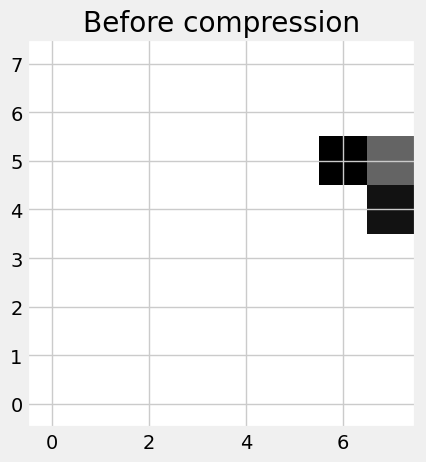

After: (1, 8, 8)
After compression


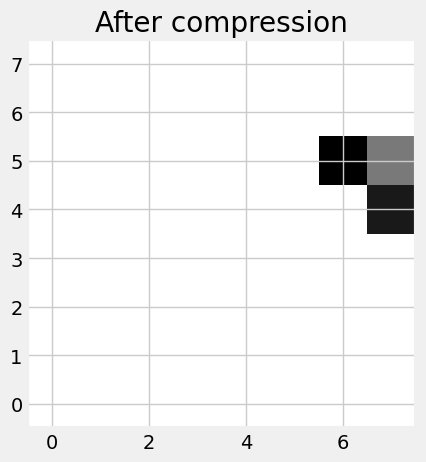

Epoch 72/80: 100%|██████████| 199/199 [00:00<00:00, 507.04it/s, Loss=0.0272]


Epoch [72/80]Average Loss: BCE = 0.0254, MSE = 5.395026143455127e-05, KL = 3.3338008837484234
Average validation set BCE loss: 0.06820748560130596


Epoch 73/80: 100%|██████████| 199/199 [00:00<00:00, 506.55it/s, Loss=0.021] 


Epoch [73/80]Average Loss: BCE = 0.0254, MSE = 5.0395530414236385e-05, KL = 3.33335767319454
Average validation set BCE loss: 0.06929980427026748


Epoch 74/80: 100%|██████████| 199/199 [00:00<00:00, 501.08it/s, Loss=0.0227]


...

Epoch [78/80]Average Loss: BCE = 0.0254, MSE = 5.036725346528429e-05, KL = 3.3269769091102943
Average validation set BCE loss: 0.06811303935945034


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 510.94it/s, Loss=0.0249]


Epoch [79/80]Average Loss: BCE = 0.0254, MSE = 4.611950987681159e-05, KL = 3.3262231050424242
Average validation set BCE loss: 0.06746124222874642


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 508.25it/s, Loss=0.026] 


Epoch [80/80]Average Loss: BCE = 0.0254, MSE = 4.588079845869736e-05, KL = 3.3264600955062176
Average validation set BCE loss: 0.06577316530048848
Saving trained model VAE


In [ ]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_kl_loss = []

# Patches
patches_before = []
patches_after = []
patches_z = [] # latent vector

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse = []

plot_val_patches_limit = 30
plot_idx = 0

model.train()

for epoch in range(num_epochs):
    train_loss = 0
    train_loss_mse = 0
    kl_loss_total = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            mu,
            logvar,
            _
        ) = model(
           X_adcs
        )
        
        loss, recon_loss, beta, kl_loss = _get_vae_loss(recon_patch, X_adcs, mu, logvar)
        
        recon_patch = recon_patch.float().to(device)      
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        
        train_loss += loss.item()
        kl_loss_total += kl_loss.item()
        
        train_loss_mse += mse(recon_patch, X_adcs).item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_loss_kl = kl_loss_total / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}]"
        f"Average Loss: BCE = {avg_loss_bce:.4f}, "
        f"MSE = {avg_loss_mse}, " 
        f"KL = {avg_loss_kl}"
    )
    
    average_loss_train.append(avg_loss_bce)
    average_loss_train_mse.append(avg_loss_mse)
    average_loss_kl_loss.append(avg_loss_kl)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss = 0
        total_mse_loss = 0
        
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
                recon_patch, 
                mu,
                logvar, 
                z 
            ) = model(patch_val)
            
            total_bce_loss += F.binary_cross_entropy(
                patch_val,
                recon_patch,
                reduction="mean"
            ).cpu().detach().numpy().item()
            
            total_mse_loss += mse(
               patch_val,
               recon_patch  
            ).item()
        
        average_loss_val = total_bce_loss / len(val_loader)
        average_loss_val_mse = total_mse_loss / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                
                patches_pairs = []
                
                for patch_val in val_loader:
                    patch_val = patch_val.to(device)           
                    
                    (
                        recon_patch, 
                        mu,
                        logvar, 
                        z
                    ) = model(patch_val)
                    
                    if len(patches_pairs) < plot_val_patches_limit:
                        patches_pairs.append((patch_val, z, recon_patch))
                
                print("Last validation batch patch mu and logvar:")
                print(
                    f"mu: mean={mu.mean().item():.4f}, std={mu.std().item():.4f} | "
                    f"logvar: mean={logvar.mean().item():.4f}, std={logvar.std().item():.4f}"
                )
                # print("Loss statistics:")
                # print(
                #     f"recon={recon_loss.item():.4f}, "
                #     f"kl={kl_loss.item():.4f}, " if beta > 0 else ""
                #     f"beta_kl={(beta * kl_loss).item():.4f}" if beta > 0 else ""
                # )
                
                if plot_idx < len(patches_pairs):
                    patch_val_before, z, patch_val_after = patches_pairs[plot_idx]
                    print("Before compression")
                    
                    patch_val_ts = _tensor_to_numpy(
                        patch_val_before.squeeze(1)
                    )
                    
                    print(f"Before: {patch_val_ts.shape}")            
                    plot_patch(patch_val_ts[0], "Before compression")
                    
                    patches_before.append(patch_val_ts[0])
                    
                    recon_patch_np = _tensor_to_numpy(
                        patch_val_after[0]
                    )
                    print(f"After: {recon_patch_np.shape}")
                    print("After compression")
                    
                    plot_patch(recon_patch_np[0], "After compression")
                
                    patches_after.append(recon_patch_np[0])  
                    z_np = _tensor_to_numpy(z[0][0])
                    patches_z.append(z_np) 
                    
                    plot_idx += 1        
            
# save model
print("Saving trained model VAE")
torch.save(model.state_dict(), "vae.pth")

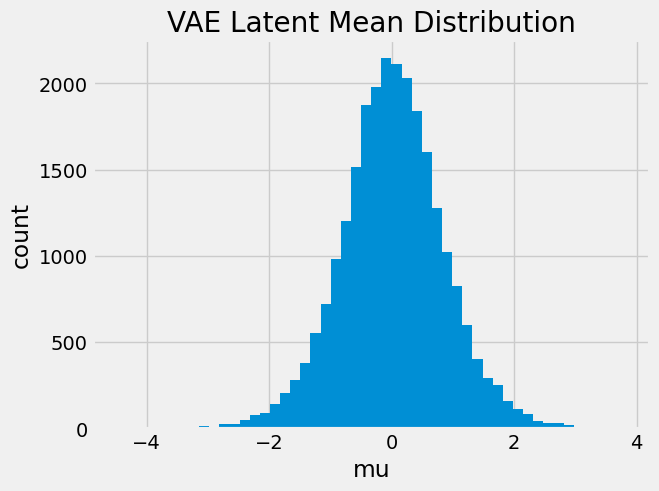

In [203]:
mu_values = mu.detach().cpu().flatten().numpy()
# histogram
plt.hist(mu_values, bins=50)

plt.title("VAE Latent Mean Distribution")
plt.xlabel("mu")
plt.ylabel("count")

plt.show()

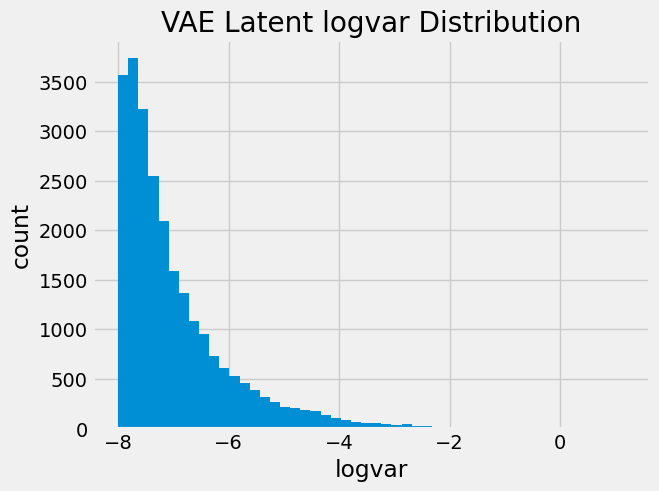

In [204]:
logvar_values = logvar.detach().cpu().flatten().numpy()
# histogram
plt.hist(logvar_values, bins=50)

plt.title("VAE Latent logvar Distribution")
plt.xlabel("logvar")
plt.ylabel("count")

plt.show()

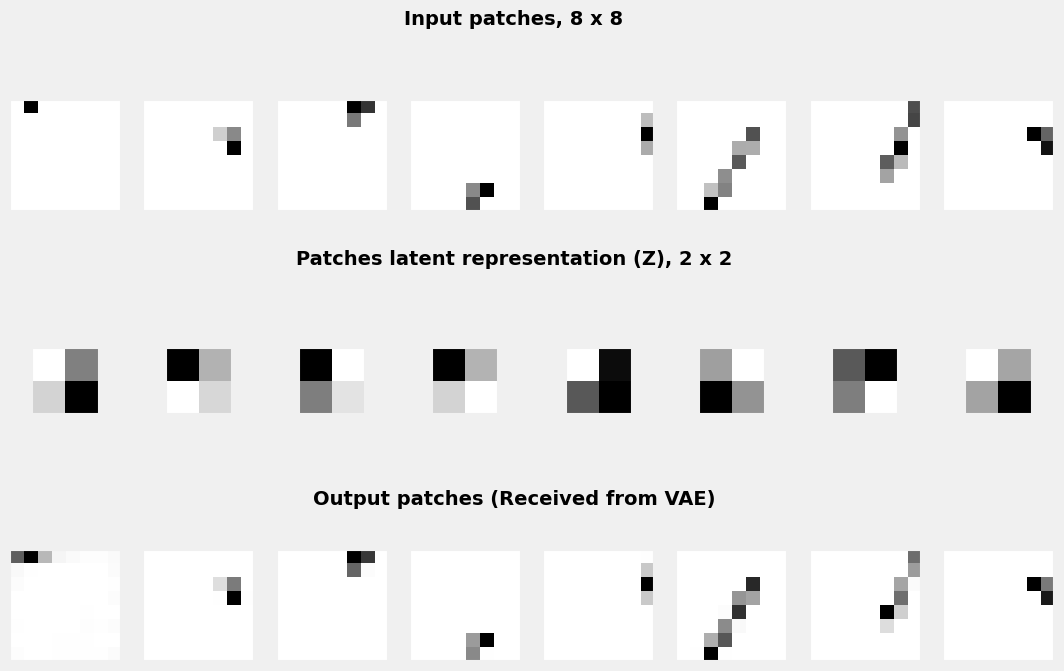

In [205]:
def plot_patches(patch_rows: list[tuple]) -> None:
    cols = len(patch_rows[0][0])
    rows = len(patch_rows)

    # fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
    fig = plt.figure(figsize=(12, 8))
    gs = GridSpec(
        3, cols,
        height_ratios=[1.5, 0.5, 1.5]
    )

    for i in range(rows):
        
        (patch_row, patch_row_title) = patch_rows[i]
        
        fig.text(
            0.5,                    # centered horizontally
            0.92 - i * 0.30,        # vertical position
            patch_row_title,
            ha='center',
            fontsize=14,
            fontweight='bold'
        )
        
        for j in range(cols):
            ax = fig.add_subplot(gs[i, j])
            
            ax.imshow(patch_row[j], cmap='gist_yarg', origin='lower')
            
            ax.set_xticks([])
            ax.set_yticks([])
            
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)

        plt.subplots_adjust(wspace=0.2, hspace=0.6)
    plt.show()
        
        
patch_rows = [
    (patches_before, "Input patches, 8 x 8"),
    (patches_z, "Patches latent representation (Z), 2 x 2"),
    (patches_after, "Output patches (Received from VAE)")
]

plot_patches(patch_rows)

In [206]:
len(patch_rows[0][0])

8

In [207]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.030560938641428947
encoder.1.weight 0.0005495369550772011
encoder.1.bias 0.0008539709961041808
encoder.3.weight 0.005373332183808088
encoder.4.weight 0.0006047546630725265
encoder.4.bias 0.00037294314824976027
encoder.6.weight 0.005878596566617489
encoder.7.weight 0.0005885658320039511
encoder.7.bias 0.00044824404176324606
fc_mean.weight 0.0031143291853368282
fc_mean.bias 0.00031207536812871695
fc_log_var.weight 0.00010886864765780047
fc_log_var.bias 1.486652126914123e-05
decoder.0.weight 0.004368775058537722
decoder.1.weight 0.000511376594658941
decoder.1.bias 0.0004084686515852809
decoder.3.weight 0.008580316789448261
decoder.4.weight 0.00046782466233707964
decoder.4.bias 0.0004641079867724329
decoder.6.weight 0.003134682308882475


VAE, Average loss values over epochs


/tmp/ipykernel_2779286/1764288248.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


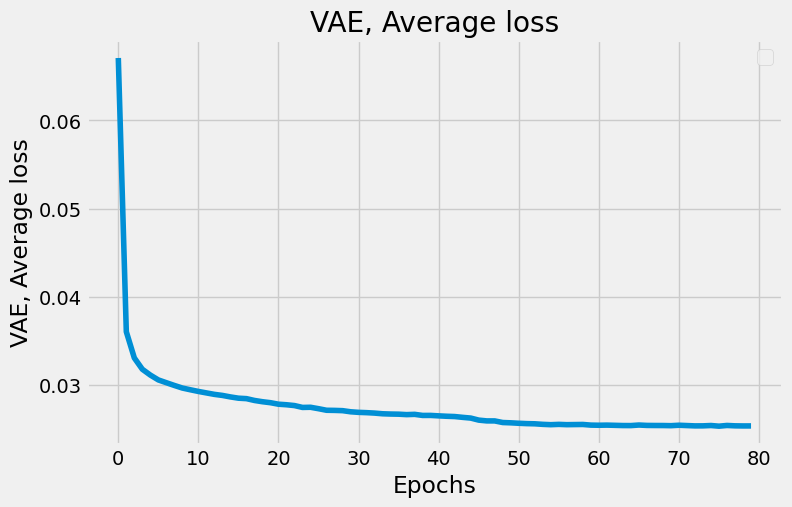

In [208]:
# display loss values
plot_metric_results(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="VAE, Average loss",
    title="VAE, Average loss",
    x_label="Epochs"
)

In [209]:
print(f"mu = {model.z_log_mean.mean().item()}")
print(f"logvar = {model.z_log_var.std().item()}")

mu = 0.017340565100312233
logvar = 1.0532817840576172


In [210]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 8
patches_after_test = []
patches_before_test = []
patches_z = [] # latent vector

bce_total_value = 0

test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        mu,
        logvar,
        z
    ) = model(patch_test)
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        z_np = _tensor_to_numpy(z[0][0])
        
        patches_z.append(z_np)
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="sum"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")

Based on test set (size = 25), average BCE loss = 251.42993


In [211]:
len(patches_before_test)

8

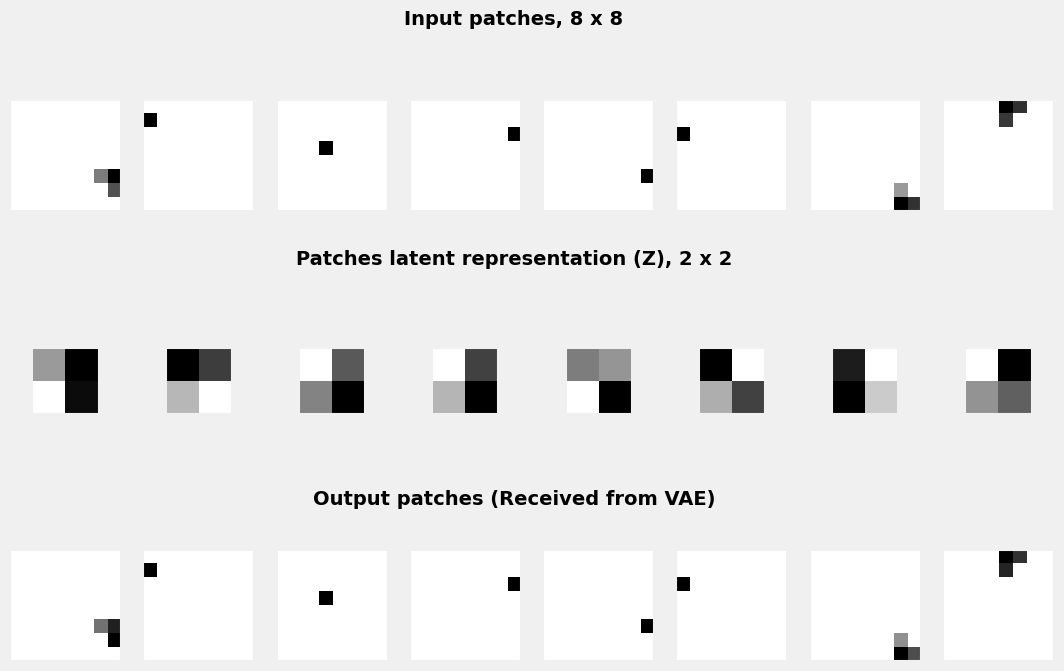

In [212]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_z, "Patches latent representation (Z), 2 x 2"),
    (patches_after_test, "Output patches (Received from VAE)")
]

plot_patches(patch_rows)

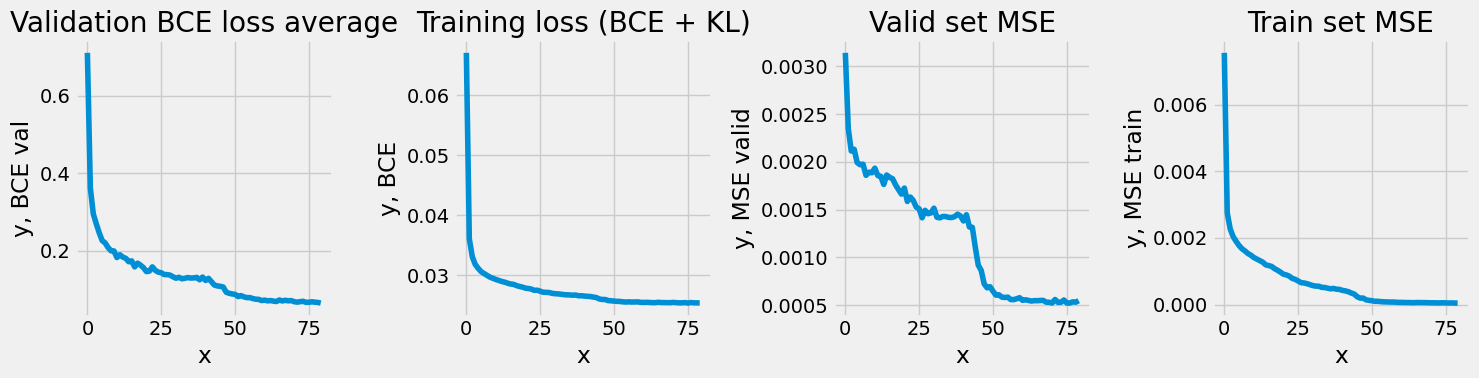

In [213]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + KL)", "BCE"),
    (list(range(len(average_loss_valid_mse))), average_loss_valid_mse, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
]

fig, axes = plt.subplots(1, len(values_to_plot), figsize=(15, 4))

for i, (x, y, title, y_label) in enumerate(values_to_plot):
    axes[i].plot(
        x,
        y,
    )
    axes[i].grid(True)
    axes[i].set_title(title)
    axes[i].set_xlabel("x")
    axes[i].set_ylabel(f"y, {y_label}")
    
    for spine in axes[i].spines.values():
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

# print(title + " values over epochs")
# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(x_values, y_values, marker=marker)
# plt.xlabel(x_label)
# plt.ylabel(y_title)
# plt.legend()
# plt.title(title)
# plt.show()

Comments
* Based on the current results,
the closer the Z latent space values are to the prior (Normal distribution),
the less stable VAE model becomes

* The more KL divergence increases, the reconstruction quality significantly drops

* If the reconstruction quality improves, z distribution becomes almost like gaussian and loss function starts to slow down after 5 epochs

* If 10 and -10 extreme values dissapear, then loss does not fall to quickly and reconstruction quality improves

* 10 and -10 extreme values appear due to high learning rate. Lerning_rate = 1e-2

* Since KL divergence is constantly growing, very small beta (scale factor) is required for the KL divergence

* Increase of latent space and hidden dimensions, marginally improved loss function

* Used 0001.root file pixel digi events for forming test, train and validation sets

* Add atleast 1 padding in network layers for preserving signal

Comment:
Need to use bigger latent dimension. Bigger than 16. Wider latent dimension,
the more information is preserved after matrix transformations
If latent dimension = 16, than noisy outputs from encoder